In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense

from utils import load_images, load_labels

SEED = 143


# Loading Data

In [10]:

x_train = load_images('MNSIT Dataset/train-images.idx3-ubyte')
x_test = load_images('MNSIT Dataset/t10k-images.idx3-ubyte')
y_train = load_labels('MNSIT Dataset/train-labels.idx1-ubyte')
y_test = load_labels('MNSIT Dataset/t10k-labels.idx1-ubyte')

# Checking Data

In [11]:
print(x_train.shape)
print(y_train.shape)

print(x_train.dtype)
print(y_train.dtype)

print(x_train.min())
print(x_train.max())

print(np.unique(y_train))

print(np.isnan(x_train).any())

(60000, 28, 28)
(60000,)
uint8
uint8
0
255
[0 1 2 3 4 5 6 7 8 9]
False


# Visualizing Data

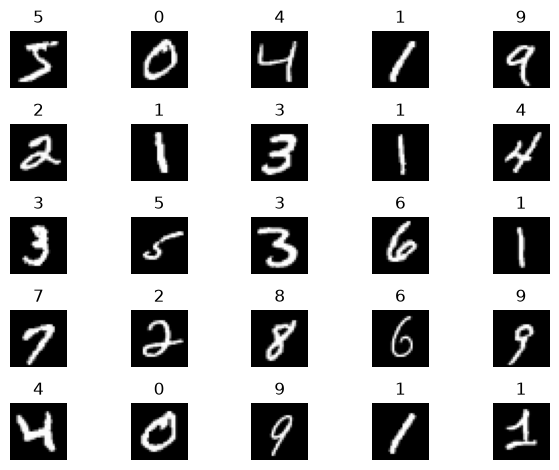

In [12]:
fig, axes = plt.subplots(5, 5)

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(int(y_train[i]))
    ax.axis('off')
    
plt.tight_layout()
plt.show()


# Scaling Model 

In [13]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# scaler = MinMaxScaler()
# x_train_scaled = scaler.fit_transform(x_train_flat)
# x_test_scaled = scaler.transform(x_test_flat)

x_train_scaled = x_train_flat.astype("float32") / 255.0
x_test_scaled = x_test_flat.astype("float32") / 255.0

In [14]:
len_labels = len(np.unique(y_train))

tf.random.set_seed(SEED)
model = tf.keras.models.Sequential([
    
    tf.keras.Input(shape=(x_test_scaled.shape[1],)),

    Dense(128, activation='relu', name='L1'),
    Dense(64, activation='relu', name='L2'),
    Dense(len_labels, activation='linear', name='L3'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001)
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
)

In [16]:

history = model.fit(
    x_train_scaled, y_train,
    validation_data=[x_test_scaled, y_test],
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50


W0000 00:00:1786724076.037369    1666 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2399

W0000 00:00:1786724091.135579    1666 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 0.2396 - val_loss: 0.1230
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.1016 - val_loss: 0.0963
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0679 - val_loss: 0.0851
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0506 - val_loss: 0.0906
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0391 - val_loss: 0.0864
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0306 - val_loss: 0.0964
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0264 - val_loss: 0.0897
